In [19]:
import os

REPO_URL = "https://github.com/pikaism/tng-anisotropy-atlas.git"
REPO_DIR = "/content/tng-anisotropy-atlas"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}

%cd {REPO_DIR}
!git pull

!pip install illustris_python --quiet

import sys
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

/content/tng-anisotropy-atlas
Already up to date.


In [22]:
import time
from pathlib import Path
import requests
from tng_io import get_api_key

HDF5_MAGIC = b"\x89HDF\r\n\x1a\n"

def is_valid_hdf5(path, min_size=1024):
    try:
        if path.stat().st_size < min_size:
            return False
        with open(path, "rb") as f:
            return f.read(8) == HDF5_MAGIC
    except OSError:
        return False

def download_groupcat_v2(snapshot, base_path, api_key=None,
                          max_retries=6, backoff=15, max_backoff=90):
    """Download groupcat chunks using the real file list from the TNG API."""
    if api_key is None:
        api_key = get_api_key()
    if api_key is None:
        raise ValueError("TNG API key not found in Colab Secrets or env.")

    headers = {"api-key": api_key}  # lowercase, per TNG docs

    # ask the API for the actual file URLs — no guessing at naming patterns
    listing_url = f"https://www.tng-project.org/api/TNG100-1/files/groupcat-{snapshot}/"
    r = requests.get(listing_url, headers=headers, timeout=30)
    r.raise_for_status()
    file_urls = r.json()["files"]
    print(f"API reports {len(file_urls)} groupcat file(s) for snapshot {snapshot}.")

    out_dir = Path(base_path) / f"groups_{snapshot:03d}"
    out_dir.mkdir(parents=True, exist_ok=True)

    downloaded = []
    for url in file_urls:
        url = url.replace("http://", "https://")  # avoid the redirect hop
        fname = url.split("/")[-1]
        out_file = out_dir / fname

        if out_file.exists() and is_valid_hdf5(out_file):
            downloaded.append(out_file)
            continue

        success = False
        for attempt in range(max_retries):
            try:
                resp = requests.get(url, headers=headers, stream=True, timeout=60)
                if resp.status_code != 200:
                    raise RuntimeError(f"status {resp.status_code}")

                with open(out_file, "wb") as f:
                    for chunk in resp.iter_content(chunk_size=8192):
                        if chunk:
                            f.write(chunk)

                if not is_valid_hdf5(out_file):
                    out_file.unlink(missing_ok=True)
                    raise RuntimeError("invalid HDF5 content")

                downloaded.append(out_file)
                print(f"[downloader] OK: {fname}")
                success = True
                break

            except (RuntimeError, requests.exceptions.RequestException) as e:
                wait = min(backoff * (attempt + 1), max_backoff)
                print(f"  [retry {attempt+1}/{max_retries}] {fname}: {e} "
                      f"— waiting {wait}s")
                time.sleep(wait)

        if not success:
            print(f"[downloader] GAVE UP on {fname} after {max_retries} attempts.")
            break

    return downloaded

In [23]:
SNAPSHOT = 99
DATA_DIR = "/content/tng_data"

downloaded_files = download_groupcat_v2(SNAPSHOT, DATA_DIR)
print(f"\nDownloaded/verified {len(downloaded_files)} groupcat chunk(s).")

API reports 448 groupcat file(s) for snapshot 99.
[downloader] OK: groupcat-99.0.hdf5
[downloader] OK: groupcat-99.1.hdf5
[downloader] OK: groupcat-99.2.hdf5
[downloader] OK: groupcat-99.3.hdf5
[downloader] OK: groupcat-99.4.hdf5
[downloader] OK: groupcat-99.5.hdf5
[downloader] OK: groupcat-99.6.hdf5
[downloader] OK: groupcat-99.7.hdf5
[downloader] OK: groupcat-99.8.hdf5
[downloader] OK: groupcat-99.9.hdf5
[downloader] OK: groupcat-99.10.hdf5
[downloader] OK: groupcat-99.11.hdf5
[downloader] OK: groupcat-99.12.hdf5
[downloader] OK: groupcat-99.13.hdf5
[downloader] OK: groupcat-99.14.hdf5
[downloader] OK: groupcat-99.15.hdf5
[downloader] OK: groupcat-99.16.hdf5
[downloader] OK: groupcat-99.17.hdf5
[downloader] OK: groupcat-99.18.hdf5
[downloader] OK: groupcat-99.19.hdf5
[downloader] OK: groupcat-99.20.hdf5
[downloader] OK: groupcat-99.21.hdf5
[downloader] OK: groupcat-99.22.hdf5
[downloader] OK: groupcat-99.23.hdf5
[downloader] OK: groupcat-99.24.hdf5
[downloader] OK: groupcat-99.25.hdf

In [24]:
import h5py
from pathlib import Path

groups_dir = Path(DATA_DIR) / f"groups_{SNAPSHOT:03d}"
all_files = sorted(groups_dir.glob("*.hdf5"))
bad_files = []

for f in all_files:
    try:
        with h5py.File(f, "r") as h:
            pass
    except OSError as e:
        bad_files.append(f)
        print(f"CORRUPTED: {f.name} ({e})")

print(f"\n{len(bad_files)} corrupted out of {len(all_files)} total files.")


0 corrupted out of 448 total files.


In [25]:
%cd /content/tng-anisotropy-atlas

new_content = '''"""TNG data I/O: authenticated download and catalog loading."""

import os
import time
from pathlib import Path

import numpy as np
import requests

HDF5_MAGIC = b"\\x89HDF\\r\\n\\x1a\\n"


def get_api_key():
    """Retrieve TNG API key from Colab Secrets or environment variables.

    Returns
    -------
    str or None
    """
    try:
        from google.colab import userdata
        key = userdata.get("TNG_API_KEY")
        if key:
            return key
    except Exception as e:
        print(f"[tng_io] Colab secrets lookup failed: {type(e).__name__}: {e}")
    return os.environ.get("TNG_API_KEY")


def _is_valid_hdf5(path, min_size=1024):
    """Check the downloaded file has the correct HDF5 magic bytes."""
    try:
        if path.stat().st_size < min_size:
            return False
        with open(path, "rb") as f:
            return f.read(8) == HDF5_MAGIC
    except OSError:
        return False


def _download_file(url, out_path, api_key, chunk_size=8192,
                    max_retries=6, backoff=15, max_backoff=90):
    """Download a single file with api-key header, retries, and HDF5 validation."""
    headers = {"api-key": api_key}
    url = url.replace("http://", "https://")

    for attempt in range(max_retries):
        try:
            r = requests.get(url, headers=headers, stream=True, timeout=60)
            if r.status_code != 200:
                raise RuntimeError(f"status {r.status_code}")

            out_path.parent.mkdir(parents=True, exist_ok=True)
            with open(out_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=chunk_size):
                    if chunk:
                        f.write(chunk)

            if not _is_valid_hdf5(out_path):
                out_path.unlink(missing_ok=True)
                raise RuntimeError("downloaded content is not valid HDF5")

            return out_path

        except (RuntimeError, requests.exceptions.RequestException) as e:
            if attempt < max_retries - 1:
                wait = min(backoff * (attempt + 1), max_backoff)
                print(f"  [retry {attempt+1}/{max_retries}] {out_path.name}: "
                      f"{e} -- waiting {wait}s")
                time.sleep(wait)
            else:
                raise


def download_groupcat(snapshot, base_path, api_key=None):
    """Download all groupcat chunks for a snapshot using the TNG API file listing.

    Parameters
    ----------
    snapshot : int
        Snapshot number (e.g. 99).
    base_path : str or Path
        Local root where ``groups_099/`` will be created.
    api_key : str, optional
        TNG API key. If None, reads from Colab Secrets or env.

    Returns
    -------
    list of Path
        Paths to downloaded (or already-present, verified) files.
    """
    if api_key is None:
        api_key = get_api_key()
    if api_key is None:
        raise ValueError(
            "TNG API key not found. Set TNG_API_KEY in Colab Secrets "
            "or as an environment variable."
        )

    headers = {"api-key": api_key}
    listing_url = f"https://www.tng-project.org/api/TNG100-1/files/groupcat-{snapshot}/"
    r = requests.get(listing_url, headers=headers, timeout=30)
    r.raise_for_status()
    file_urls = r.json()["files"]

    out_dir = Path(base_path) / f"groups_{snapshot:03d}"
    out_dir.mkdir(parents=True, exist_ok=True)

    downloaded = []
    for url in file_urls:
        fname = url.split("/")[-1]
        out_file = out_dir / fname

        if out_file.exists() and _is_valid_hdf5(out_file):
            downloaded.append(out_file)
            continue

        _download_file(url, out_file, api_key)
        downloaded.append(out_file)
        print(f"[tng_io] downloaded {fname}")

    return downloaded


def load_catalogs(snapshot, base_path, group_fields=None, sub_fields=None):
    """Load group and subhalo catalogs via illustris_python.

    Parameters
    ----------
    snapshot : int
    base_path : str or Path
    group_fields : list of str, optional
    sub_fields : list of str, optional

    Returns
    -------
    group_cat, sub_cat, header : dict, dict, dict
    """
    import illustris_python as il

    base_path = str(base_path)
    group_cat = il.groupcat.loadHalos(base_path, snapshot, fields=group_fields)
    sub_cat = il.groupcat.loadSubhalos(base_path, snapshot, fields=sub_fields)
    header = il.groupcat.loadHeader(base_path, snapshot)
    return group_cat, sub_cat, header
'''

with open("src/tng_io.py", "w") as f:
    f.write(new_content)

print("src/tng_io.py updated.")

/content/tng-anisotropy-atlas
src/tng_io.py updated.


In [27]:
!git config --global user.email "your_email@example.com"
!git config --global user.name "pikaism"

In [28]:
!git add src/tng_io.py
!git commit -m "Fix tng_io: correct groupcat file URLs via API listing, lowercase api-key header, add HDF5 validation and retry logic"
!git push

[main 68dc4ec] Fix tng_io: correct groupcat file URLs via API listing, lowercase api-key header, add HDF5 validation and retry logic
 1 file changed, 62 insertions(+), 34 deletions(-)
fatal: could not read Username for 'https://github.com': No such device or address


In [34]:
import requests

token = "PASTE_YOUR_TOKEN_HERE"  # same one you just tried

r = requests.get(
    "https://api.github.com/user",
    headers={"Authorization": f"token {token}"}
)
print("Status:", r.status_code)
print(r.json())

Status: 401
{'message': 'Bad credentials', 'documentation_url': 'https://docs.github.com/rest', 'status': '401'}


In [36]:
from google.colab import userdata

token = userdata.get("GIT_API_KEY")

print("Type:", type(token))
print("Length:", len(token) if token else "None/empty")
print("Starts with 'ghp_':", token.startswith("ghp_") if token else "N/A")
print("First 6 chars:", token[:6] if token else "N/A")
print("Last 4 chars:", token[-4:] if token else "N/A")
print("Contains whitespace:", token != token.strip() if token else "N/A")

Type: <class 'str'>
Length: 40
Starts with 'ghp_': True
First 6 chars: ghp_eE
Last 4 chars: ivWA
Contains whitespace: False


In [37]:
import requests
from google.colab import userdata

token = userdata.get("GIT_API_KEY")

r = requests.get(
    "https://api.github.com/user",
    headers={"Authorization": f"token {token}"}
)
print("Status:", r.status_code)
print(r.json())

Status: 200
{'login': 'pikaism', 'id': 321021629, 'node_id': 'U_kgDOEyJmvQ', 'avatar_url': 'https://avatars.githubusercontent.com/u/321021629?v=4', 'gravatar_id': '', 'url': 'https://api.github.com/users/pikaism', 'html_url': 'https://github.com/pikaism', 'followers_url': 'https://api.github.com/users/pikaism/followers', 'following_url': 'https://api.github.com/users/pikaism/following{/other_user}', 'gists_url': 'https://api.github.com/users/pikaism/gists{/gist_id}', 'starred_url': 'https://api.github.com/users/pikaism/starred{/owner}{/repo}', 'subscriptions_url': 'https://api.github.com/users/pikaism/subscriptions', 'organizations_url': 'https://api.github.com/users/pikaism/orgs', 'repos_url': 'https://api.github.com/users/pikaism/repos', 'events_url': 'https://api.github.com/users/pikaism/events{/privacy}', 'received_events_url': 'https://api.github.com/users/pikaism/received_events', 'type': 'User', 'user_view_type': 'public', 'site_admin': False, 'name': 'Shivangi Gupta ', 'company

In [42]:
push_url = f"https://{fresh_token}@github.com/pikaism/tng-anisotropy-atlas.git"
!git push {push_url} main

Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 1.34 KiB | 1.34 MiB/s, done.
Total 4 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
remote: This repository moved. Please use the new location:
remote:   https://github.com/pikaism/TNG-anisotropy-atlas.git
To https://github.com/pikaism/tng-anisotropy-atlas.git
   bf53a9b..68dc4ec  main -> main


In [43]:
REPO_URL = "https://github.com/pikaism/TNG-anisotropy-atlas.git"

In [44]:
import h5py
from pathlib import Path

groups_dir = Path(DATA_DIR) / f"groups_{SNAPSHOT:03d}"
all_files = sorted(groups_dir.glob("*.hdf5"))
bad_files = []

for f in all_files:
    try:
        with h5py.File(f, "r") as h:
            pass
    except OSError as e:
        bad_files.append(f)
        print(f"CORRUPTED: {f.name} ({e})")

print(f"\n{len(bad_files)} corrupted out of {len(all_files)} total files.")


0 corrupted out of 448 total files.


In [45]:
import sys
sys.path.insert(0, "/content/tng-anisotropy-atlas/src")  # in case session restarted

from tng_io import load_catalogs

group_fields = ["GroupPos", "GroupVel", "Group_M_Crit200", "Group_R_Crit200",
                "GroupNsubs", "GroupFirstSub"]
sub_fields = ["SubhaloPos", "SubhaloVel", "SubhaloMassType", "SubhaloSFR",
              "SubhaloFlag", "SubhaloGrNr"]

group_cat, sub_cat, header = load_catalogs(
    SNAPSHOT, DATA_DIR,
    group_fields=group_fields,
    sub_fields=sub_fields,
)

box_size = header["BoxSize"]
print("Box size (ckpc/h):", box_size)
print("N groups:", group_cat["count"])
print("N subhalos:", sub_cat["count"])

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/tng_data/groups_099/fof_subhalo_tab_099.0.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [46]:
from pathlib import Path

groups_dir = Path(DATA_DIR) / f"groups_{SNAPSHOT:03d}"
existing_files = sorted(groups_dir.glob("*.hdf5"))
print(f"Found {len(existing_files)} files")
print("Sample names:", [f.name for f in existing_files[:5]])

Found 448 files
Sample names: ['groupcat-99.0.hdf5', 'groupcat-99.1.hdf5', 'groupcat-99.10.hdf5', 'groupcat-99.100.hdf5', 'groupcat-99.101.hdf5']


In [47]:
import re

renamed = 0
for f in existing_files:
    # extract the chunk number from whatever pattern we actually have
    match = re.search(r"\.(\d+)\.hdf5$", f.name)
    if match is None:
        print(f"Skipping unrecognized filename: {f.name}")
        continue

    chunk_num = match.group(1)
    new_name = f"fof_subhalo_tab_{SNAPSHOT:03d}.{chunk_num}.hdf5"
    new_path = groups_dir / new_name

    if not new_path.exists():
        f.rename(new_path)
        renamed += 1

print(f"Renamed {renamed} files.")

# sanity check
new_files = sorted(groups_dir.glob("fof_subhalo_tab_*.hdf5"))
print(f"Now {len(new_files)} files matching expected pattern.")
print("Sample:", [f.name for f in new_files[:5]])

Renamed 448 files.
Now 448 files matching expected pattern.
Sample: ['fof_subhalo_tab_099.0.hdf5', 'fof_subhalo_tab_099.1.hdf5', 'fof_subhalo_tab_099.10.hdf5', 'fof_subhalo_tab_099.100.hdf5', 'fof_subhalo_tab_099.101.hdf5']


In [48]:
from tng_io import load_catalogs

group_fields = ["GroupPos", "GroupVel", "Group_M_Crit200", "Group_R_Crit200",
                "GroupNsubs", "GroupFirstSub"]
sub_fields = ["SubhaloPos", "SubhaloVel", "SubhaloMassType", "SubhaloSFR",
              "SubhaloFlag", "SubhaloGrNr"]

group_cat, sub_cat, header = load_catalogs(
    SNAPSHOT, DATA_DIR,
    group_fields=group_fields,
    sub_fields=sub_fields,
)

box_size = header["BoxSize"]
print("Box size (ckpc/h):", box_size)
print("N groups:", group_cat["count"])
print("N subhalos:", sub_cat["count"])

Box size (ckpc/h): 75000.0
N groups: 6291349
N subhalos: 4371211


/tmp/ipykernel_2263/508838241.py:4: RuntimeWarning: divide by zero encountered in log10
  logm = np.log10(group_cat["Group_M_Crit200"])


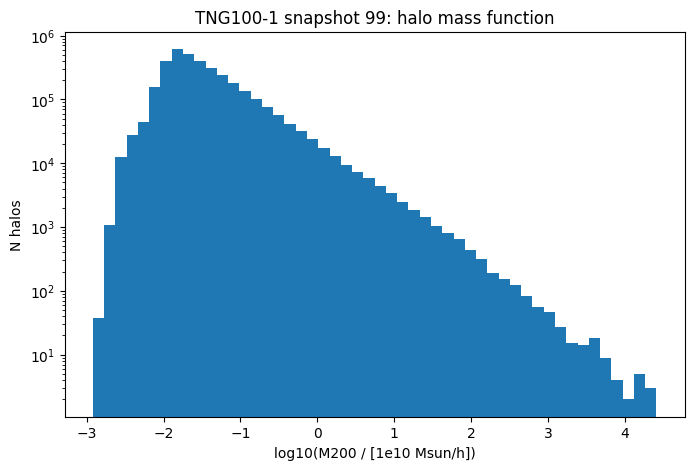

Total halos with M200 > 0: 3423724
log10(M200) range: [-2.92, 4.41]

Test bin counts:
  [1.0, 1.3): 4723 halos
  [1.3, 1.7): 3288 halos
  [1.7, 2.2): 1754 halos
  [2.2, 3.0): 645 halos


In [49]:
import numpy as np
import matplotlib.pyplot as plt

logm = np.log10(group_cat["Group_M_Crit200"])
logm = logm[np.isfinite(logm) & (group_cat["Group_M_Crit200"] > 0)]

plt.figure(figsize=(8, 5))
plt.hist(logm, bins=50)
plt.xlabel("log10(M200 / [1e10 Msun/h])")
plt.ylabel("N halos")
plt.yscale("log")
plt.title(f"TNG100-1 snapshot {SNAPSHOT}: halo mass function")
plt.show()

print(f"Total halos with M200 > 0: {len(logm)}")
print(f"log10(M200) range: [{logm.min():.2f}, {logm.max():.2f}]")

# starting guess — we'll tune based on what the histogram shows
test_edges = [1.0, 1.3, 1.7, 2.2, 3.0]
print("\nTest bin counts:")
for lo, hi in zip(test_edges[:-1], test_edges[1:]):
    n = np.sum((logm >= lo) & (logm < hi))
    print(f"  [{lo}, {hi}): {n} halos")

In [50]:
cluster_edges = [3.0, 3.5, 3.8, 4.0, 4.5]
print("High-mass tail counts:")
for lo, hi in zip(cluster_edges[:-1], cluster_edges[1:]):
    n = np.sum((logm >= lo) & (logm < hi))
    mass_msun = 10**((lo+hi)/2) * 1e10
    print(f"  log10 M200 in [{lo}, {hi})  (~{mass_msun:.1e} Msun/h): {n} halos")

High-mass tail counts:
  log10 M200 in [3.0, 3.5)  (~1.8e+13 Msun/h): 84 halos
  log10 M200 in [3.5, 3.8)  (~4.5e+13 Msun/h): 26 halos
  log10 M200 in [3.8, 4.0)  (~7.9e+13 Msun/h): 7 halos
  log10 M200 in [4.0, 4.5)  (~1.8e+14 Msun/h): 10 halos


In [51]:
final_logm_edges = [(1.0, 1.3), (1.3, 1.7), (1.7, 2.2), (2.2, 3.0), (3.0, 4.5)]

print("Final mass bins:")
for lo, hi in final_logm_edges:
    n = np.sum((logm >= lo) & (logm < hi))
    mass_lo = 10**lo * 1e10
    mass_hi = 10**hi * 1e10
    print(f"  log10 M200 [{lo}, {hi})  →  M200 ≈ [{mass_lo:.1e}, {mass_hi:.1e}] Msun/h  →  {n} halos")

Final mass bins:
  log10 M200 [1.0, 1.3)  →  M200 ≈ [1.0e+11, 2.0e+11] Msun/h  →  4723 halos
  log10 M200 [1.3, 1.7)  →  M200 ≈ [2.0e+11, 5.0e+11] Msun/h  →  3288 halos
  log10 M200 [1.7, 2.2)  →  M200 ≈ [5.0e+11, 1.6e+12] Msun/h  →  1754 halos
  log10 M200 [2.2, 3.0)  →  M200 ≈ [1.6e+12, 1.0e+13] Msun/h  →  645 halos
  log10 M200 [3.0, 4.5)  →  M200 ≈ [1.0e+13, 3.2e+14] Msun/h  →  127 halos


In [52]:
from halo_sample import select_host_halos

hosts = select_host_halos(group_cat, final_logm_edges, min_nsubs=6)

for i, h in enumerate(hosts):
    lo, hi = final_logm_edges[i]
    print(f"Bin {i} [{lo}, {hi}): {len(h['indices'])} host halos (after min_nsubs=6 cut)")

Bin 0 [1.0, 1.3): 3911 host halos (after min_nsubs=6 cut)
Bin 1 [1.3, 1.7): 3208 host halos (after min_nsubs=6 cut)
Bin 2 [1.7, 2.2): 1754 host halos (after min_nsubs=6 cut)
Bin 3 [2.2, 3.0): 645 host halos (after min_nsubs=6 cut)
Bin 4 [3.0, 4.5): 127 host halos (after min_nsubs=6 cut)


/content/tng-anisotropy-atlas/src/halo_sample.py:46: RuntimeWarning: divide by zero encountered in log10
  logm = np.log10(mass)


In [53]:
from halo_sample import build_satellite_catalog

def build_all_satellites(hosts, sub_cat, box_size, min_stellar_mass=0.0):
    """Build satellite pos/vel/props for every host halo in every mass bin.

    Returns
    -------
    list of dict
        One entry per mass bin, each with a "halos" list of per-host dicts
        containing host_idx, r200, logm, pos, vel, props.
    """
    results = []
    for bin_hosts in hosts:
        bin_result = {"halos": []}
        for j, host_idx in enumerate(bin_hosts["indices"]):
            host_props = {
                "pos": bin_hosts["pos"][j],
                "vel": bin_hosts["vel"][j],
                "r200": bin_hosts["r200"][j],
                "first_sub": bin_hosts["first_sub"][j],
            }
            rel_pos, rel_vel, props = build_satellite_catalog(
                sub_cat, host_idx, host_props, box_size,
                min_stellar_mass=min_stellar_mass,
            )
            if rel_pos is None:
                continue
            bin_result["halos"].append({
                "host_idx": host_idx,
                "r200": host_props["r200"],
                "logm": bin_hosts["logm"][j],
                "pos": rel_pos,
                "vel": rel_vel,
                "props": props,
            })
        results.append(bin_result)
    return results

satellite_data = build_all_satellites(hosts, sub_cat, box_size)

for i, bin_result in enumerate(satellite_data):
    n_halos_with_sats = len(bin_result["halos"])
    total_sats = sum(len(h["pos"]) for h in bin_result["halos"])
    print(f"Mass bin {i}: {n_halos_with_sats} halos with satellites, "
          f"{total_sats} satellites total")

Mass bin 0: 3878 halos with satellites, 19320 satellites total
Mass bin 1: 3205 halos with satellites, 29705 satellites total
Mass bin 2: 1754 halos with satellites, 41828 satellites total
Mass bin 3: 645 halos with satellites, 69177 satellites total
Mass bin 4: 127 halos with satellites, 145865 satellites total


In [54]:
import pickle

with open("/content/satellite_data.pkl", "wb") as f:
    pickle.dump(satellite_data, f)

print("Saved satellite_data.pkl")

# ALSO save to Google Drive so it survives even if /content wipes
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy("/content/satellite_data.pkl", "/content/drive/MyDrive/satellite_data.pkl")
print("Backed up to Google Drive.")

Saved satellite_data.pkl
Mounted at /content/drive
Backed up to Google Drive.


In [55]:
import numpy as np
from kinematics import radial_tangential_split, beta_profile

def stack_beta_profile(bin_halos, n_bins=8, n_min=20, n_bootstrap=200, seed=42):
    """Stack satellites across halos (scaled by R200) and compute beta(r)
    with bootstrap errors resampling over halos.

    Parameters
    ----------
    bin_halos : list of dict
        Each dict has "pos", "vel", "r200" for one halo.
    n_bins : int
    n_min : int
    n_bootstrap : int
    seed : int

    Returns
    -------
    centers, beta, beta_err, edges, n_halos_used
    """
    rng = np.random.default_rng(seed)
    n_halos = len(bin_halos)

    def stacked_r_vr_vt(halo_subset):
        all_r, all_vr, all_vt = [], [], []
        for h in halo_subset:
            r, vr, vt = radial_tangential_split(h["pos"], h["vel"])
            r_scaled = r / h["r200"]
            all_r.append(r_scaled)
            all_vr.append(vr)
            all_vt.append(vt)
        return np.concatenate(all_r), np.concatenate(all_vr), np.concatenate(all_vt)

    # main measurement: all halos in this bin
    r_all, vr_all, vt_all = stacked_r_vr_vt(bin_halos)

    # beta_profile expects pos/vel, not raw r/vr/vt, so we build a small
    # wrapper that works directly from r, vr, vt using the same binning logic
    def beta_from_rvrvt(r, vr, vt, n_bins, n_min):
        edges = np.quantile(r, np.linspace(0, 1, n_bins + 1))
        edges[-1] += 1e-10
        centers, betas = [], []
        for i in range(n_bins):
            mask = (r >= edges[i]) & (r < edges[i + 1])
            n = mask.sum()
            if n < n_min:
                centers.append(np.nan)
                betas.append(np.nan)
                continue
            vr_b, vt_b = vr[mask], vt[mask]
            st2 = np.mean(vt_b ** 2)
            sr2 = np.var(vr_b, ddof=1)
            if sr2 == 0:
                centers.append(np.nan)
                betas.append(np.nan)
                continue
            beta = 1.0 - st2 / (2.0 * sr2)
            centers.append(0.5 * (edges[i] + edges[i + 1]))
            betas.append(beta)
        return np.array(centers), np.array(betas), edges

    centers, beta_main, edges = beta_from_rvrvt(r_all, vr_all, vt_all, n_bins, n_min)

    # bootstrap: resample HALOS with replacement, recompute stacked beta each time
    boot_betas = np.full((n_bootstrap, n_bins), np.nan)
    for b in range(n_bootstrap):
        idx = rng.integers(0, n_halos, size=n_halos)
        subset = [bin_halos[i] for i in idx]
        r_b, vr_b, vt_b = stacked_r_vr_vt(subset)
        _, beta_b, _ = beta_from_rvrvt(r_b, vr_b, vt_b, n_bins, n_min)
        boot_betas[b] = beta_b

    beta_err = np.nanstd(boot_betas, axis=0)

    return centers, beta_main, beta_err, edges, n_halos

In [56]:
stacked_results = []

for i, bin_result in enumerate(satellite_data):
    halos_with_sats = bin_result["halos"]
    if len(halos_with_sats) < 5:
        print(f"Bin {i}: too few halos ({len(halos_with_sats)}), skipping")
        stacked_results.append(None)
        continue

    centers, beta, beta_err, edges, n_halos = stack_beta_profile(
        halos_with_sats, n_bins=8, n_min=20, n_bootstrap=200, seed=100 + i
    )
    stacked_results.append({
        "centers": centers, "beta": beta, "beta_err": beta_err,
        "edges": edges, "n_halos": n_halos,
    })
    print(f"Bin {i}: stacked {n_halos} halos, beta range "
          f"[{np.nanmin(beta):.2f}, {np.nanmax(beta):.2f}]")

Bin 0: stacked 3878 halos, beta range [-0.32, -0.03]
Bin 1: stacked 3205 halos, beta range [-0.18, -0.05]
Bin 2: stacked 1754 halos, beta range [-0.18, -0.03]
Bin 3: stacked 645 halos, beta range [-0.06, 0.02]
Bin 4: stacked 127 halos, beta range [0.07, 0.24]


In [57]:
from scipy.spatial import cKDTree

def compute_environment_counts(group_cat, box_size, radius_mpc_h=5.0,
                                mass_threshold_logm=1.0):
    """Count neighboring halos within a fixed radius, using periodic wrapping.

    Parameters
    ----------
    group_cat : dict
    box_size : float, ckpc/h
    radius_mpc_h : float
        Search radius in Mpc/h (converted internally to ckpc/h).
    mass_threshold_logm : float
        Only count neighbors above this log10(M200) threshold (avoids
        counting every tiny subhalo as a "neighbor").

    Returns
    -------
    ndarray, shape (N_groups,)
        Neighbor count for every group (NaN-safe: 0 if isolated).
    """
    pos = group_cat["GroupPos"]
    mass = group_cat["Group_M_Crit200"]
    logm = np.full_like(mass, -np.inf)
    valid_mass = mass > 0
    logm[valid_mass] = np.log10(mass[valid_mass])

    massive_mask = logm >= mass_threshold_logm
    massive_pos = pos[massive_mask]
    massive_idx = np.where(massive_mask)[0]

    radius_ckpc = radius_mpc_h * 1000.0  # Mpc/h -> ckpc/h

    # periodic KDTree handles box wraparound automatically
    tree = cKDTree(massive_pos, boxsize=box_size)

    counts = np.zeros(len(pos), dtype=int)
    # query only for the massive subset (positions we care about for hosts)
    neighbor_lists = tree.query_ball_point(massive_pos, r=radius_ckpc)
    for local_i, neighbors in enumerate(neighbor_lists):
        global_i = massive_idx[local_i]
        counts[global_i] = len(neighbors) - 1  # subtract self

    return counts

env_counts = compute_environment_counts(group_cat, box_size, radius_mpc_h=5.0)
print("Environment counts computed. Range:", env_counts.min(), "to", env_counts.max())

Environment counts computed. Range: 0 to 78


In [58]:
def classify_sf_quenched(props, ssfr_threshold=1e-11):
    """Classify satellites as star-forming or quenched via specific SFR.

    Parameters
    ----------
    props : dict
        Must contain "sfr" and "stellar_mass" (code units: 1e10 Msun/h).
    ssfr_threshold : float
        sSFR threshold in 1/yr; below this is "quenched". 1e-11/yr is a
        commonly used literature threshold (e.g. Franx et al. 2008).

    Returns
    -------
    is_quenched : ndarray of bool
    """
    stellar_mass_msun = props["stellar_mass"] * 1e10  # convert to Msun/h
    with np.errstate(divide="ignore", invalid="ignore"):
        ssfr = props["sfr"] / stellar_mass_msun
    is_quenched = (ssfr < ssfr_threshold) | (props["sfr"] == 0)
    return is_quenched

In [59]:
from scipy.stats import spearmanr

mean_betas = []
mean_logm = []
mean_env = []

for i, (bin_result, stacked) in enumerate(zip(satellite_data, stacked_results)):
    if stacked is None:
        continue
    valid = ~np.isnan(stacked["beta"])
    if valid.sum() == 0:
        continue
    mean_betas.append(np.nanmean(stacked["beta"]))
    halo_logms = [h["logm"] for h in bin_result["halos"]]
    mean_logm.append(np.mean(halo_logms))

    halo_idxs = [h["host_idx"] for h in bin_result["halos"]]
    mean_env.append(np.mean(env_counts[halo_idxs]))

mean_betas = np.array(mean_betas)
mean_logm = np.array(mean_logm)
mean_env = np.array(mean_env)

rho_mass, p_mass = spearmanr(mean_logm, mean_betas)
rho_env, p_env = spearmanr(mean_env, mean_betas)

print(f"Spearman(beta, log M200): rho={rho_mass:.3f}, p={p_mass:.3f}")
print(f"Spearman(beta, environment): rho={rho_env:.3f}, p={p_env:.3f}")

Spearman(beta, log M200): rho=1.000, p=0.000
Spearman(beta, environment): rho=1.000, p=0.000
